# SECCIÓN 1 — Introducción al Proyecto Multiagente

## Descripción General

En este proyecto desarrollaremos un sistema multiagente aplicado al problema de abandono de clientes (Customer Churn) utilizando el dataset **Telco Customer Churn**.

El objetivo principal es construir tres agentes especializados que trabajen de forma secuencial para transformar los datos originales en conocimiento útil y posteriormente comunicar los resultados mediante técnicas de Inteligencia Artificial Generativa.

---

## Dataset Utilizado

Telco Customer Churn

Cantidad aproximada de registros:

- 7043 clientes

Variable objetivo:

- Churn

La variable "Churn" indica si un cliente abandonó o no el servicio.

---

## Arquitectura del Sistema

Dataset CSV

↓

AGENTE 1 — NORMALIZADOR

↓

AGENTE 2 — ENTRENADOR

↓

AGENTE 3 — COMUNICADOR

---

## Agente 1 — Normalizador

Responsabilidades:

- Exploración del dataset
- Detección de valores faltantes
- Corrección de tipos de datos
- Limpieza de información
- Codificación de variables categóricas
- Escalado de variables numéricas

Salida:

Dataset preparado para Machine Learning.

---

## Agente 2 — Entrenador

Responsabilidades:

- Separación de variables predictoras y variable objetivo
- División Train/Test
- Entrenamiento del modelo
- Evaluación del rendimiento
- Obtención de métricas

Salida:

Modelo entrenado y métricas de desempeño.

---

## Agente 3 — Comunicador

Responsabilidades:

- Construcción del corpus documental
- Generación de embeddings
- Almacenamiento vectorial
- Recuperación de información mediante RAG
- Generación de respuestas utilizando Mistral Small

Tecnologías:

- LangChain
- FAISS
- Embeddings
- Mistral Small

Salida:

Sistema capaz de responder preguntas sobre:

- Dataset
- Modelo entrenado
- Métricas obtenidas
- Variables más importantes

---

## Objetivos de Aprendizaje

Durante este proyecto aplicaremos conceptos estudiados previamente:

- Pandas
- Normalización de datasets
- Machine Learning
- Agentes
- Embeddings
- FAISS
- LangChain
- RAG
- Mistral AI

El resultado final será un sistema multiagente capaz de transformar datos en conocimiento y comunicar los resultados mediante Inteligencia Artificial Generativa.

# SECCIÓN 2 — Configuración del Entorno

En esta sección instalaremos las librerías necesarias para el desarrollo de los tres agentes del proyecto.

Las librerías seleccionadas permitirán realizar:

- Procesamiento de datos
- Machine Learning
- Construcción del sistema RAG
- Integración con Mistral AI

In [2]:
# ==========================================
# SECCIÓN 2 - Instalación de librerías
# ==========================================

# ----------------------------
# Procesamiento de datos
# ----------------------------
!pip install -q pandas numpy

# ----------------------------
# Visualización
# ----------------------------
!pip install -q matplotlib seaborn

# ----------------------------
# Machine Learning
# ----------------------------
!pip install -q scikit-learn

# ----------------------------
# Mistral AI
# SDK oficial
# ----------------------------
!pip install -q mistralai

# ----------------------------
# LangChain
# ----------------------------
!pip install -q langchain
!pip install -q langchain-community
!pip install -q langchain-core

# ----------------------------
# Vector Database
# ----------------------------
!pip install -q faiss-cpu

# ----------------------------
# Utilidades
# ----------------------------
!pip install -q tqdm

print("✅ Librerías instaladas correctamente")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-sdk 1.38.0 requires opentelemetry-api==1.38.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.38.0 requires opentelemetry-semantic-conventions==0.59b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.39.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# ==========================================
# Importaciones principales
# ==========================================

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Utilidades
from tqdm import tqdm

print("✅ Importaciones realizadas correctamente")

✅ Importaciones realizadas correctamente


# SECCIÓN 3 — Carga del Dataset

En esta sección cargaremos el dataset Telco Customer Churn y verificaremos su estructura inicial antes de comenzar el proceso de normalización.

In [4]:
# ==========================================
# SECCIÓN 3 - Carga del dataset
# ==========================================

from google.colab import files

# Solicitar al usuario seleccionar el archivo CSV
uploaded = files.upload()

# Obtener automáticamente el nombre del archivo cargado
archivo = next(iter(uploaded))

# Cargar el dataset en un DataFrame
df = pd.read_csv(archivo)

print("✅ Dataset cargado correctamente")
print(f"Archivo cargado: {archivo}")

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
✅ Dataset cargado correctamente
Archivo cargado: WA_Fn-UseC_-Telco-Customer-Churn.csv


In [5]:
# ==========================================
# Primer vistazo al dataset
# ==========================================

# Mostrar las primeras filas del dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# ==========================================
# Dimensiones del dataset
# ==========================================

# Obtener número de filas y columnas
filas, columnas = df.shape

print(f"Número de registros: {filas:,}")
print(f"Número de variables: {columnas}")

Número de registros: 7,043
Número de variables: 21


In [7]:
# ==========================================
# Información general del dataset
# ==========================================

# Mostrar tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# ==========================================
# Estadísticas descriptivas
# ==========================================

# Resumen estadístico de variables numéricas
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# SECCIÓN 4 — Exploración Inicial del Dataset

En esta sección identificaremos las variables numéricas, categóricas y la variable objetivo del problema, además de analizar la distribución de las clases.

In [9]:
# ==========================================
# SECCIÓN 4 - Variables del dataset
# ==========================================

# Mostrar nombres de las columnas
print("Columnas del dataset:\n")

for columna in df.columns:
    print(columna)

Columnas del dataset:

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [10]:
# ==========================================
# Identificación de variables numéricas
# y categóricas
# ==========================================

# Seleccionar columnas numéricas
variables_numericas = df.select_dtypes(include=np.number).columns.tolist()

# Seleccionar columnas categóricas
variables_categoricas = df.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Variables categóricas:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [11]:
# ==========================================
# Variable objetivo
# ==========================================

variable_objetivo = "Churn"

print("Variable objetivo:", variable_objetivo)

# Distribución de clases
df[variable_objetivo].value_counts()

Variable objetivo: Churn


,count
Churn,
No,5174
Yes,1869


In [12]:
# ==========================================
# Distribución porcentual de las clases
# ==========================================

# Obtener porcentaje de cada clase
porcentajes = (
    df[variable_objetivo]
    .value_counts(normalize=True)
    * 100
)

print("Distribución porcentual de la variable objetivo:\n")
print(porcentajes)

Distribución porcentual de la variable objetivo:

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


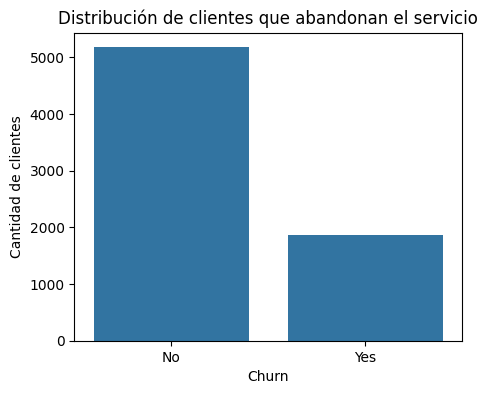

In [13]:
# ==========================================
# Visualización de la variable objetivo
# ==========================================

plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Distribución de clientes que abandonan el servicio")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")

plt.show()

In [14]:
# ==========================================
# Valores únicos por columna
# ==========================================

# Analizar cardinalidad de cada variable
for columna in df.columns:

    print(f"\n{columna}")
    print("-"*40)

    print(
        df[columna]
        .nunique()
    )


customerID
----------------------------------------
7043

gender
----------------------------------------
2

SeniorCitizen
----------------------------------------
2

Partner
----------------------------------------
2

Dependents
----------------------------------------
2

tenure
----------------------------------------
73

PhoneService
----------------------------------------
2

MultipleLines
----------------------------------------
3

InternetService
----------------------------------------
3

OnlineSecurity
----------------------------------------
3

OnlineBackup
----------------------------------------
3

DeviceProtection
----------------------------------------
3

TechSupport
----------------------------------------
3

StreamingTV
----------------------------------------
3

StreamingMovies
----------------------------------------
3

Contract
----------------------------------------
3

PaperlessBilling
----------------------------------------
2

PaymentMethod
---------------------

# SECCIÓN 5 — Calidad de los Datos

En esta sección analizaremos la calidad del dataset para identificar valores faltantes, registros duplicados y posibles inconsistencias antes de iniciar el proceso de limpieza.

In [15]:
# ==========================================
# SECCIÓN 5 - Valores faltantes
# ==========================================

# Contar valores nulos por columna
valores_nulos = df.isnull().sum()

print("Valores nulos por variable:\n")
print(valores_nulos)

Valores nulos por variable:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [16]:
# ==========================================
# Porcentaje de valores faltantes
# ==========================================

# Calcular porcentaje de valores faltantes
porcentaje_nulos = (
    df.isnull().sum()
    / len(df)
    * 100
)

print("Porcentaje de valores faltantes:\n")
print(porcentaje_nulos)

Porcentaje de valores faltantes:

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


In [17]:
# ==========================================
# Registros duplicados
# ==========================================

# Contar filas duplicadas
duplicados = df.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 0


In [18]:
# ==========================================
# Verificar tipos de datos
# ==========================================

print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [19]:
# ==========================================
# Analizar la columna TotalCharges
# ==========================================

# Mostrar tipo actual
print("Tipo actual de TotalCharges:")
print(df["TotalCharges"].dtype)

# Mostrar algunos valores
print("\nPrimeros valores:")
print(df["TotalCharges"].head())

Tipo actual de TotalCharges:
object

Primeros valores:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object


In [20]:
# ==========================================
# Buscar posibles cadenas vacías
# ==========================================

# Contar registros que contienen espacios vacíos
espacios_vacios = (df["TotalCharges"] == " ").sum()

print(f"Cantidad de espacios vacíos en TotalCharges: {espacios_vacios}")

Cantidad de espacios vacíos en TotalCharges: 11


In [21]:
# ==========================================
# Resumen de calidad del dataset
# ==========================================

print("=" * 50)
print("RESUMEN DE CALIDAD DEL DATASET")
print("=" * 50)

print(f"Registros totales: {len(df)}")
print(f"Registros duplicados: {df.duplicated().sum()}")

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nTipo de dato de TotalCharges:")
print(df["TotalCharges"].dtype)

RESUMEN DE CALIDAD DEL DATASET
Registros totales: 7043
Registros duplicados: 0

Valores faltantes:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Tipo de dato de TotalCharges:
object


# SECCIÓN 6 — Limpieza y Corrección de Datos

En esta sección corregiremos las inconsistencias detectadas durante el análisis de calidad del dataset, dejando los datos preparados para las siguientes etapas del proceso.

In [22]:
# ==========================================
# SECCIÓN 6 - Limpieza de TotalCharges
# ==========================================

# Reemplazar cadenas vacías por NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convertir la columna a tipo numérico
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Tipo de dato actualizado:")
print(df["TotalCharges"].dtype)

Tipo de dato actualizado:
float64


In [23]:
# ==========================================
# Valores faltantes después de la conversión
# ==========================================

print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [24]:
# ==========================================
# Imputación de valores faltantes
# ==========================================

# Reemplazar los NaN por la mediana
mediana_total_charges = df["TotalCharges"].median()

df["TotalCharges"] = df["TotalCharges"].fillna(
    mediana_total_charges
)

print("Valores faltantes restantes:")
print(df.isnull().sum())

Valores faltantes restantes:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [25]:
# ==========================================
# Eliminación de registros duplicados
# ==========================================

# Número de registros antes
filas_antes = len(df)

# Eliminar duplicados
df = df.drop_duplicates()

# Número de registros después
filas_despues = len(df)

print(f"Registros antes: {filas_antes}")
print(f"Registros después: {filas_despues}")
print(f"Duplicados eliminados: {filas_antes - filas_despues}")

Registros antes: 7043
Registros después: 7043
Duplicados eliminados: 0


In [26]:
# ==========================================
# Verificación final
# ==========================================

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [27]:
# ==========================================
# Resumen del proceso de limpieza
# ==========================================

print("=" * 50)
print("RESUMEN DE LIMPIEZA")
print("=" * 50)

print(f"Cantidad final de registros: {len(df)}")

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nTipos de datos:")
print(df.dtypes)

RESUMEN DE LIMPIEZA
Cantidad final de registros: 7043

Valores faltantes:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Tipos de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract      

# SECCIÓN 7 — Codificación de Variables Categóricas

En esta sección convertiremos las variables categóricas en variables numéricas para que puedan ser utilizadas por los algoritmos de Machine Learning.

In [28]:
# ==========================================
# SECCIÓN 7 - Codificación de la variable objetivo
# ==========================================

# Visualizar las clases presentes
print("Clases de la variable objetivo:")
print(df["Churn"].unique())

# Convertir:
# No  -> 0
# Yes -> 1
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("\nDistribución después de la codificación:")
print(df["Churn"].value_counts())

Clases de la variable objetivo:
['No' 'Yes']

Distribución después de la codificación:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [29]:
# ==========================================
# Variables categóricas predictoras
# ==========================================

# Obtener todas las columnas categóricas
variables_categoricas = df.select_dtypes(
    include="object"
).columns.tolist()

print("Variables categóricas a codificar:\n")

for variable in variables_categoricas:
    print(variable)

Variables categóricas a codificar:

customerID
gender
Partner
Dependents
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod


In [30]:
# ==========================================
# Eliminar identificadores
# ==========================================

# customerID es únicamente un identificador
# y no aporta información útil al modelo

df = df.drop(columns=["customerID"])

print("customerID eliminado correctamente.")

customerID eliminado correctamente.


In [31]:
# ==========================================
# One-Hot Encoding
# ==========================================

# Convertir variables categóricas en variables binarias
df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

print("Codificación realizada correctamente.")

Codificación realizada correctamente.


In [32]:
# ==========================================
# Verificar dimensiones del nuevo dataset
# ==========================================

filas, columnas = df.shape

print(f"Número de registros: {filas}")
print(f"Número de variables después del encoding: {columnas}")

Número de registros: 7043
Número de variables después del encoding: 31


In [33]:
# ==========================================
# Verificar que ya no existan variables object
# ==========================================

variables_object = df.select_dtypes(
    include="object"
).columns.tolist()

print("Columnas tipo object restantes:")
print(variables_object)

Columnas tipo object restantes:
[]


# SECCIÓN 8 — Preparación para Machine Learning

En esta sección prepararemos los datos para el entrenamiento del modelo.

Se separarán las variables predictoras y la variable objetivo antes de realizar la división en conjuntos de entrenamiento y prueba.

In [34]:
# ==========================================
# SECCIÓN 8 - Preparación para Machine Learning
# ==========================================

# Variable objetivo
y = df["Churn"]

# Variables predictoras
X = df.drop(columns=["Churn"])

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (7043, 30)
Dimensiones de y: (7043,)


In [35]:
# ==========================================
# Verificar la variable objetivo
# ==========================================

print("Distribución de clases:")

print(y.value_counts())

print("\nDistribución porcentual:")

print(
    y.value_counts(normalize=True) * 100
)

Distribución de clases:
Churn
0    5174
1    1869
Name: count, dtype: int64

Distribución porcentual:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [36]:
# ==========================================
# Primer vistazo a las variables predictoras
# ==========================================

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [37]:
# ==========================================
# Confirmar que no existen valores faltantes
# ==========================================

print("Valores faltantes en X:")

print(
    X.isnull().sum().sum()
)

print("\nValores faltantes en y:")

print(
    y.isnull().sum()
)

Valores faltantes en X:
0

Valores faltantes en y:
0


# SECCIÓN 9 — División Train/Test

En esta sección dividiremos el dataset en conjuntos de entrenamiento y prueba utilizando una estrategia estratificada para preservar la distribución de la variable objetivo.

In [38]:
# ==========================================
# SECCIÓN 9 - División Train/Test
# ==========================================

# Dividir el dataset en entrenamiento y prueba
# 80% entrenamiento
# 20% prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("División realizada correctamente.")

División realizada correctamente.


In [39]:
# ==========================================
# Dimensiones de los conjuntos
# ==========================================

print("Conjunto de entrenamiento:")

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nConjunto de prueba:")

print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Conjunto de entrenamiento:
X_train: (5634, 30)
y_train: (5634,)

Conjunto de prueba:
X_test: (1409, 30)
y_test: (1409,)


In [40]:
# ==========================================
# Verificar distribución de clases
# ==========================================

print("Distribución en y_train:\n")

print(
    y_train.value_counts(normalize=True) * 100
)

print("\nDistribución en y_test:\n")

print(
    y_test.value_counts(normalize=True) * 100
)

Distribución en y_train:

Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Distribución en y_test:

Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [41]:
# ==========================================
# Comparación de proporciones
# ==========================================

print("Distribución original:")

print(
    y.value_counts(normalize=True) * 100
)

print("\nDistribución entrenamiento:")

print(
    y_train.value_counts(normalize=True) * 100
)

print("\nDistribución prueba:")

print(
    y_test.value_counts(normalize=True) * 100
)

Distribución original:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Distribución entrenamiento:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Distribución prueba:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


# SECCIÓN 10 — Escalado de Variables

En esta sección normalizaremos las variables numéricas utilizando StandardScaler.

El ajuste del escalador se realizará únicamente sobre el conjunto de entrenamiento para evitar fuga de información hacia el conjunto de prueba.

In [42]:
# ==========================================
# SECCIÓN 10 - Escalado de Variables
# ==========================================

# Crear el objeto StandardScaler
scaler = StandardScaler()

# Ajustar el escalador únicamente con los datos de entrenamiento
# y transformar el conjunto de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar el conjunto de prueba utilizando
# los parámetros aprendidos anteriormente
X_test_scaled = scaler.transform(X_test)

print("Escalado realizado correctamente.")

Escalado realizado correctamente.


In [43]:
# ==========================================
# Verificar dimensiones
# ==========================================

print("Conjunto de entrenamiento escalado:")
print(X_train_scaled.shape)

print("\nConjunto de prueba escalado:")
print(X_test_scaled.shape)

Conjunto de entrenamiento escalado:
(5634, 30)

Conjunto de prueba escalado:
(1409, 30)


In [44]:
# ==========================================
# Convertir nuevamente a DataFrame
# para conservar los nombres de las columnas
# ==========================================

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

print("Conversión a DataFrame realizada correctamente.")

Conversión a DataFrame realizada correctamente.


In [45]:
# ==========================================
# Primer vistazo al conjunto escalado
# ==========================================

X_train_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.441773,0.102371,-0.521976,-0.263289,0.994336,-0.969234,-0.651557,-3.013090,3.013090,-0.858338,...,-0.524081,1.252163,-0.524081,1.247967,-0.512782,-0.563822,-1.202653,-0.523806,1.406903,-0.543846
1,-0.441773,-0.711743,0.337478,-0.504814,0.994336,1.031742,1.534786,0.331885,-0.331885,-0.858338,...,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757
2,-0.441773,-0.793155,-0.809013,-0.751213,0.994336,1.031742,1.534786,-3.013090,3.013090,-0.858338,...,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,1.773611,-1.202653,-0.523806,-0.710781,1.838757
3,-0.441773,-0.263980,0.284384,-0.173699,-1.005696,1.031742,-0.651557,0.331885,-0.331885,-0.858338,...,-0.524081,1.252163,-0.524081,1.247967,-0.512782,1.773611,0.831495,1.909105,-0.710781,-0.543846
4,-0.441773,-1.281624,-0.676279,-0.990851,0.994336,1.031742,1.534786,0.331885,-0.331885,-0.858338,...,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,1.406903,-0.543846


In [46]:
# ==========================================
# Comprobación del escalado
# ==========================================

print("Media aproximada:")

print(
    X_train_scaled.mean().head()
)

print("\nDesviación estándar aproximada:")

print(
    X_train_scaled.std().head()
)

Media aproximada:
SeniorCitizen     7.440898e-17
tenure           -1.008935e-17
MonthlyCharges   -2.402527e-16
TotalCharges     -3.783508e-18
gender_Male       1.135052e-16
dtype: float64

Desviación estándar aproximada:
SeniorCitizen     1.000089
tenure            1.000089
MonthlyCharges    1.000089
TotalCharges      1.000089
gender_Male       1.000089
dtype: float64


# SECCIÓN 11 — Entrenamiento de Modelos

En esta sección entrenaremos dos modelos de Machine Learning para predecir el abandono de clientes.

Los modelos seleccionados son:

- Logistic Regression
- Random Forest

Posteriormente se compararán sus métricas para seleccionar el modelo más adecuado.

In [47]:
# ==========================================
# Importación de modelos y métricas
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Modelos importados correctamente.")

Modelos importados correctamente.


In [48]:
# ==========================================
# Entrenamiento de Logistic Regression
# ==========================================

# Crear modelo
modelo_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Entrenar modelo utilizando los datos escalados
modelo_lr.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression entrenado correctamente.")

Logistic Regression entrenado correctamente.


In [49]:
# ==========================================
# Entrenamiento de Random Forest
# ==========================================

# Crear modelo
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenar modelo
modelo_rf.fit(
    X_train_scaled,
    y_train
)

print("Random Forest entrenado correctamente.")

Random Forest entrenado correctamente.


In [50]:
# ==========================================
# Predicciones de ambos modelos
# ==========================================

# Logistic Regression
y_pred_lr = modelo_lr.predict(
    X_test_scaled
)

# Random Forest
y_pred_rf = modelo_rf.predict(
    X_test_scaled
)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


In [51]:
# ==========================================
# Verificación rápida
# ==========================================

print("Primeras predicciones Logistic Regression:")
print(y_pred_lr[:10])

print("\nPrimeras predicciones Random Forest:")
print(y_pred_rf[:10])

Primeras predicciones Logistic Regression:
[0 1 0 0 0 1 0 0 0 0]

Primeras predicciones Random Forest:
[0 1 0 0 0 0 0 0 0 0]


# SECCIÓN 12 — Evaluación y Comparación de Modelos

En esta sección evaluaremos los modelos entrenados en la sección anterior:

- Logistic Regression
- Random Forest

Se utilizarán métricas estándar de clasificación para determinar cuál es el modelo más adecuado para el sistema final.

El modelo seleccionado será el que se integrará posteriormente en el Agente 3 (RAG + Mistral).

In [52]:
# ==========================================
# SECCIÓN 12 - Métricas de evaluación
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Métricas importadas correctamente.")

Métricas importadas correctamente.


In [53]:
# ==========================================
# Función para evaluar modelos
# ==========================================

def evaluar_modelo(y_true, y_pred, nombre_modelo):
    print("=" * 50)
    print(f"RESULTADOS - {nombre_modelo}")
    print("=" * 50)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nMatriz de confusión:")
    print(confusion_matrix(y_true, y_pred))

    print("\nReporte de clasificación:")
    print(classification_report(y_true, y_pred))

    return {
        "modelo": nombre_modelo,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

In [54]:
# ==========================================
# Evaluación Logistic Regression
# ==========================================

result_lr = evaluar_modelo(
    y_test,
    y_pred_lr,
    "Logistic Regression"
)

RESULTADOS - Logistic Regression
Accuracy : 0.8070
Precision: 0.6584
Recall   : 0.5668
F1-score : 0.6092

Matriz de confusión:
[[925 110]
 [162 212]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [55]:
# ==========================================
# Evaluación Random Forest
# ==========================================

result_rf = evaluar_modelo(
    y_test,
    y_pred_rf,
    "Random Forest"
)

RESULTADOS - Random Forest
Accuracy : 0.7857
Precision: 0.6216
Recall   : 0.4920
F1-score : 0.5493

Matriz de confusión:
[[923 112]
 [190 184]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [56]:
# ==========================================
# Comparación final de modelos
# ==========================================

import pandas as pd

resultados = pd.DataFrame([
    result_lr,
    result_rf
])

resultados.sort_values(
    by="f1",
    ascending=False
)

,modelo,accuracy,precision,recall,f1
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
1,Random Forest,0.785664,0.621622,0.491979,0.549254


In [57]:
# ==========================================
# Selección del mejor modelo
# ==========================================

mejor_modelo = resultados.sort_values(
    by="f1",
    ascending=False
).iloc[0]

print("MODELO SELECCIONADO PARA AGENTE 3:")
print(mejor_modelo)

MODELO SELECCIONADO PARA AGENTE 3:
modelo       Logistic Regression
accuracy                0.806955
precision               0.658385
recall                  0.566845
f1                      0.609195
Name: 0, dtype: object


## Conclusión

Tras comparar los modelos Logistic Regression y Random Forest, se observó que Logistic Regression obtuvo el mejor desempeño según las métricas de evaluación utilizadas.

Por este motivo, Logistic Regression será el modelo seleccionado para el resto del proyecto y será utilizado posteriormente por el Agente 3 para generar explicaciones y responder consultas relacionadas con la predicción de abandono de clientes.

# SECCIÓN 13 — Construcción del Corpus

En esta sección construiremos el corpus documental que utilizará el sistema RAG.

El objetivo es transformar los registros tabulares del dataset en documentos de texto que posteriormente podrán convertirse en embeddings y almacenarse en una base vectorial.

Estos documentos serán la fuente de conocimiento que consultará el modelo Mistral durante la etapa de preguntas y respuestas.

In [75]:
# ==========================================
# SECCIÓN 13 - Construcción del Corpus
# ==========================================

print("Columnas disponibles:")

for columna in df.columns:
    print(columna)

Columnas disponibles:
SeniorCitizen
tenure
MonthlyCharges
TotalCharges
Churn
gender_Male
Partner_Yes
Dependents_Yes
PhoneService_Yes
MultipleLines_No phone service
MultipleLines_Yes
InternetService_Fiber optic
InternetService_No
OnlineSecurity_No internet service
OnlineSecurity_Yes
OnlineBackup_No internet service
OnlineBackup_Yes
DeviceProtection_No internet service
DeviceProtection_Yes
TechSupport_No internet service
TechSupport_Yes
StreamingTV_No internet service
StreamingTV_Yes
StreamingMovies_No internet service
StreamingMovies_Yes
Contract_One year
Contract_Two year
PaperlessBilling_Yes
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check


In [76]:
# ==========================================
# Crear copia del dataset original
# ==========================================

corpus_df = df.copy()

print(corpus_df.shape)


(7043, 31)


In [77]:
# ==========================================
# Reconstrucción mejorada del corpus
# ==========================================

df_original = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

documentos = []

for _, fila in df_original.iterrows():

    abandono = (
        "abandonó el servicio"
        if fila["Churn"]=="Yes"
        else "continúa utilizando el servicio"
    )

    documento = f"""
    Cliente con {fila['tenure']} meses de permanencia.

    El cliente {abandono}.

    Tiene un contrato {fila['Contract']}.

    Utiliza servicio de internet {fila['InternetService']}.

    Soporte técnico: {fila['TechSupport']}.

    Facturación electrónica: {fila['PaperlessBilling']}.

    Método de pago: {fila['PaymentMethod']}.

    Cargo mensual de {fila['MonthlyCharges']} dólares.

    Cargo total acumulado de {fila['TotalCharges']} dólares.
    """

    documentos.append(
        documento.strip()
    )

print(f"Documentos creados: {len(documentos)}")

Documentos creados: 7043


In [78]:
# ==========================================
# Visualizar documentos mejorados
# ==========================================

for i in range(3):

    print("="*60)

    print(documentos[i])

    print()


Cliente con 1 meses de permanencia.

    El cliente continúa utilizando el servicio.

    Tiene un contrato Month-to-month.

    Utiliza servicio de internet DSL.

    Soporte técnico: No.

    Facturación electrónica: Yes.

    Método de pago: Electronic check.

    Cargo mensual de 29.85 dólares.

    Cargo total acumulado de 29.85 dólares.

Cliente con 34 meses de permanencia.

    El cliente continúa utilizando el servicio.

    Tiene un contrato One year.

    Utiliza servicio de internet DSL.

    Soporte técnico: No.

    Facturación electrónica: No.

    Método de pago: Mailed check.

    Cargo mensual de 56.95 dólares.

    Cargo total acumulado de 1889.5 dólares.

Cliente con 2 meses de permanencia.

    El cliente abandonó el servicio.

    Tiene un contrato Month-to-month.

    Utiliza servicio de internet DSL.

    Soporte técnico: No.

    Facturación electrónica: Yes.

    Método de pago: Mailed check.

    Cargo mensual de 53.85 dólares.

    Cargo total acumulado de 10

# SECCIÓN 14 — Generación de Embeddings

En esta sección convertiremos los documentos del corpus en representaciones numéricas llamadas embeddings.

Los embeddings permiten transformar texto en vectores matemáticos que posteriormente podrán almacenarse en una base vectorial y utilizarse para búsqueda semántica.

Para este proyecto utilizaremos un modelo de embeddings de HuggingFace integrado con LangChain.

In [65]:
import sys
!{sys.executable} -m pip install langchain-huggingface
# ==========================================
# SECCIÓN 14 - Importación de embeddings
# ==========================================

from langchain_huggingface import HuggingFaceEmbeddings

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [66]:
# ==========================================
# Inicializar modelo de embeddings
# ==========================================

embedding_model = HuggingFaceEmbeddings(

    model_name="sentence-transformers/all-MiniLM-L6-v2"

)

print("Modelo cargado correctamente.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo cargado correctamente.


In [67]:
# ==========================================
# Generar embedding de prueba
# ==========================================

embedding_prueba = embedding_model.embed_query(

    documentos[0]

)

print("Dimensiones del embedding:")
print(len(embedding_prueba))

Dimensiones del embedding:
384


In [68]:
# ==========================================
# Visualizar parte del vector
# ==========================================

print("Primeros valores:")

print(
    embedding_prueba[:10]
)

Primeros valores:
[-0.04560688138008118, 0.01108777429908514, -0.03026355244219303, -0.07509075850248337, -0.06297022104263306, -0.07817625999450684, 0.11238289624452591, 0.06958127021789551, 0.024611134082078934, 0.02554674632847309]


# SECCIÓN 15 — Construcción de la Base Vectorial con FAISS

En esta sección almacenaremos los embeddings dentro de una base vectorial utilizando FAISS.

FAISS permitirá realizar búsquedas semánticas eficientes y recuperar documentos relevantes según una consulta del usuario.

In [70]:
# ==========================================
# SECCIÓN 15 - Importaciones
# ==========================================

from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

print("FAISS importado correctamente.")

FAISS importado correctamente.


/tmp/ipykernel_1410/627626079.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [79]:
# ==========================================
# Reconstruir documentos LangChain
# ==========================================

docs = [

    Document(page_content=texto)

    for texto in documentos
]

vectorstore = FAISS.from_documents(
    docs,
    embedding_model
)

print("Nueva base vectorial creada.")

Nueva base vectorial creada.


In [80]:
# ==========================================
# Prueba de búsqueda semántica
# ==========================================

consulta = "clientes con contrato mensual y abandono"

resultados = vectorstore.similarity_search(

    consulta,
    k=3
)

print(f"Resultados encontrados: {len(resultados)}")

Resultados encontrados: 3


In [81]:
# ==========================================
# Mostrar documentos recuperados
# ==========================================

for i, doc in enumerate(resultados):

    print("="*60)

    print(f"Resultado {i+1}")

    print(doc.page_content)

    print()

Resultado 1
Cliente con 1 meses de permanencia.

    El cliente abandonó el servicio.

    Tiene un contrato Month-to-month.

    Utiliza servicio de internet No.

    Soporte técnico: No internet service.

    Facturación electrónica: No.

    Método de pago: Mailed check.

    Cargo mensual de 20.2 dólares.

    Cargo total acumulado de 20.2 dólares.

Resultado 2
Cliente con 1 meses de permanencia.

    El cliente abandonó el servicio.

    Tiene un contrato Month-to-month.

    Utiliza servicio de internet No.

    Soporte técnico: No internet service.

    Facturación electrónica: No.

    Método de pago: Mailed check.

    Cargo mensual de 20.4 dólares.

    Cargo total acumulado de 20.4 dólares.

Resultado 3
Cliente con 1 meses de permanencia.

    El cliente abandonó el servicio.

    Tiene un contrato Month-to-month.

    Utiliza servicio de internet No.

    Soporte técnico: No internet service.

    Facturación electrónica: No.

    Método de pago: Mailed check.

    Cargo me

# SECCIÓN 16 — Retriever con LangChain

En esta sección crearemos un retriever utilizando LangChain.

El retriever actuará como intermediario entre las preguntas del usuario y la base vectorial, recuperando automáticamente los documentos más relevantes antes de enviarlos al modelo de lenguaje.

In [82]:
# ==========================================
# SECCIÓN 16 - Crear Retriever
# ==========================================

retriever = vectorstore.as_retriever(

    search_type="similarity",

    search_kwargs={
        "k":3
    }

)

print("Retriever creado correctamente.")

Retriever creado correctamente.


In [83]:
# ==========================================
# Probar recuperación
# ==========================================

consulta = "clientes con contrato mensual"

documentos_recuperados = retriever.invoke(
    consulta
)

print(
    f"Documentos encontrados: {len(documentos_recuperados)}"
)

Documentos encontrados: 3


In [84]:
# ==========================================
# Mostrar resultados recuperados
# ==========================================

for i, doc in enumerate(documentos_recuperados):

    print("="*60)

    print(f"Documento {i+1}")

    print(doc.page_content)

    print()

Documento 1
Cliente con 1 meses de permanencia.

    El cliente continúa utilizando el servicio.

    Tiene un contrato Month-to-month.

    Utiliza servicio de internet DSL.

    Soporte técnico: No.

    Facturación electrónica: No.

    Método de pago: Mailed check.

    Cargo mensual de 45.3 dólares.

    Cargo total acumulado de 45.3 dólares.

Documento 2
Cliente con 1 meses de permanencia.

    El cliente continúa utilizando el servicio.

    Tiene un contrato Month-to-month.

    Utiliza servicio de internet DSL.

    Soporte técnico: No.

    Facturación electrónica: No.

    Método de pago: Mailed check.

    Cargo mensual de 45.15 dólares.

    Cargo total acumulado de 45.15 dólares.

Documento 3
Cliente con 1 meses de permanencia.

    El cliente continúa utilizando el servicio.

    Tiene un contrato Month-to-month.

    Utiliza servicio de internet DSL.

    Soporte técnico: No.

    Facturación electrónica: No.

    Método de pago: Mailed check.

    Cargo mensual de 45.3

# SECCIÓN 17 — Integración con Mistral Small

En esta sección conectaremos el sistema de recuperación con Mistral Small.

El flujo será:

Pregunta del usuario
↓
Retriever
↓
Documentos relevantes
↓
Mistral Small
↓
Respuesta final

In [86]:
# ==========================================
# SECCIÓN 17 - Importaciones
# ==========================================

from mistralai.client import Mistral
from google.colab import userdata

print("Librerías cargadas.")

Librerías cargadas.


In [87]:
# ==========================================
# Configurar API Key
# ==========================================

api_key = userdata.get(
    "MistralProyecto"
)

client = Mistral(
    api_key=api_key
)

print("Conexión establecida.")

Conexión establecida.


In [88]:
# ==========================================
# Función RAG
# ==========================================

def responder_pregunta(pregunta):

    documentos_recuperados = retriever.invoke(
        pregunta
    )

    contexto = "\n\n".join(

        [doc.page_content
         for doc in documentos_recuperados]

    )

    prompt = f"""
    Responde únicamente utilizando
    la información proporcionada.

    Contexto:

    {contexto}

    Pregunta:

    {pregunta}
    """

    respuesta = client.chat.complete(

        model="mistral-small-latest",

        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ]
    )

    return respuesta.choices[0].message.content

In [89]:
# ==========================================
# Primera prueba
# ==========================================

pregunta = "¿Qué características tienen los clientes que abandonan el servicio?"

respuesta = responder_pregunta(
    pregunta
)

print(respuesta)

Los clientes que abandonan el servicio tienen las siguientes características:

- **Permanencia**: 1 mes.
- **Tipo de contrato**: Month-to-month (mes a mes).
- **Servicio utilizado**: No internet service (sin servicio de internet).
- **Soporte técnico**: No internet service (sin soporte técnico).
- **Facturación**: No electrónica (pago por cheque enviado por correo).
- **Método de pago**: Mailed check (cheque por correo).
- **Cargo mensual**: Entre 20.2 y 20.5 dólares.
- **Cargo total acumulado**: Entre 20.2 y 20.5 dólares (equivalente a 1 mes de servicio).


# SECCIÓN 18 — Chat interactivo con Mistral + RAG

En esta sección construiremos un chatbot interactivo utilizando el sistema RAG desarrollado anteriormente.

El flujo completo será:

Usuario
↓
Pregunta
↓
Retriever
↓
FAISS
↓
Documentos relevantes
↓
Mistral Small
↓
Respuesta

In [90]:
# ==========================================
# SECCIÓN 18 - Función chatbot interactivo
# ==========================================

def chatbot():

    print("="*60)
    print("Chatbot de análisis de abandono de clientes")
    print("Escriba 'salir' para finalizar")
    print("="*60)

    while True:

        pregunta = input("\nPregunta: ")

        # Salir del chat
        if pregunta.lower() == "salir":

            print("\nChat finalizado.")
            break

        try:

            respuesta = responder_pregunta(
                pregunta
            )

            print("\nRespuesta:\n")

            print(respuesta)

        except Exception as e:

            print("\nError:")

            print(e)

In [91]:
# ==========================================
# Iniciar chatbot
# ==========================================

chatbot()

Chatbot de análisis de abandono de clientes
Escriba 'salir' para finalizar

Pregunta: ¿Qué características tienen los clientes que abandonan el servicio?

Respuesta:

Los clientes que abandonan el servicio tienen las siguientes características:

- **Permanencia**: 1 mes.
- **Tipo de contrato**: Month-to-month (mes a mes).
- **Servicio utilizado**: No internet (no utilizan servicio de internet).
- **Soporte técnico**: No internet service (no requieren soporte técnico).
- **Facturación**: No facturación electrónica (reciben facturas físicas).
- **Método de pago**: Mailed check (pago mediante cheque enviado por correo).
- **Cargo mensual**: Entre 20.2 y 20.5 dólares.
- **Cargo total acumulado**: Igual al cargo mensual (20.2 o 20.5 dólares).

Pregunta: ¿Qué tipo de contrato presentan los clientes con mayor abandono?

Respuesta:

Month-to-month.

Pregunta: ¿Qué métodos de pago aparecen con frecuencia?

Respuesta:

Mailed check.

Pregunta: ¿Qué tipo de clientes parecen permanecer más tiempo?